## Notebook 03 — Momentum Signal Construction

This notebook constructs rolling momentum signals for all assets across three lookback windows and analyses their statistical properties and cross-asset relationships.

The momentum signal for asset $i$ at time $t$ with lookback $w$ is:

$$M_{i,t}^{(w)} = \ln\left(\frac{P_{i,t}}{P_{i,t-w}}\right) = \sum_{\tau=1}^{w} r_{i,t-\tau+1}$$

**Lookback windows:** w ∈ {5, 10, 20} trading days

**Sections:**
1. Load processed data
2. Construct momentum signals
3. Signal visualisation
4. Signal correlation across windows
5. Signal autocorrelation
6. Lead-lag scatter plots (hypothesised pairs)
7. Save signals

---
### 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

PROC_DIR = os.path.join("..", "data", "processed")
FIG_DIR  = os.path.join("..", "figures")
os.makedirs(PROC_DIR, exist_ok=True)

COMMODITIES = ["WTI", "Brent", "Copper", "NatGas", "Gold"]
EQUITIES    = ["XLE", "XLB", "GDX"]
ALL_ASSETS  = COMMODITIES + EQUITIES

PAIRS = [
    ("WTI",    "XLE"),
    ("Brent",  "XLE"),
    ("Copper", "XLB"),
    ("Gold",   "GDX"),
    ("NatGas", "XLE"),
]

COLORS = {
    "WTI"   : "#e07b39",
    "Brent" : "#e0a039",
    "Copper": "#b5651d",
    "NatGas": "#6b8e23",
    "Gold"  : "#c5a028",
    "XLE"   : "#4a9eda",
    "XLB"   : "#6dbf6d",
    "GDX"   : "#c47fd4",
}

WINDOWS = [5, 10, 20]

# Load
returns = pd.read_csv(
    os.path.join(PROC_DIR, "log_returns.csv"),
    index_col=0, parse_dates=True
)
close = pd.read_csv(
    os.path.join(PROC_DIR, "close_prices_clean.csv"),
    index_col=0, parse_dates=True
)

print(f"Returns shape : {returns.shape}")
print(f"Close shape   : {close.shape}")
print(f"Date range    : {returns.index[0].date()} → {returns.index[-1].date()}")

Returns shape : (4122, 8)
Close shape   : (4125, 8)
Date range    : 2010-01-05 → 2026-05-22


---
### 2. Construct Momentum Signals

We compute the rolling sum of log returns over each lookback window. This is equivalent to the log price ratio $\ln(P_t / P_{t-w})$.

In [2]:
# momentum[w] is a DataFrame of shape (T, 8) — one signal per asset per window
momentum = {}

for w in WINDOWS:
    mom = returns.rolling(w).sum()
    mom.columns = ALL_ASSETS
    momentum[w] = mom
    print(f"w={w:>2} | shape={mom.shape} | NaNs introduced={mom.isna().any(axis=1).sum()}")

# Quick sanity check: compare rolling sum vs log price ratio for WTI, w=5
log_ratio = np.log(close["WTI"] / close["WTI"].shift(5))
roll_sum  = returns["WTI"].rolling(5).sum()
diff      = (log_ratio - roll_sum).dropna().abs().max()
print(f"\nSanity check max diff (log ratio vs rolling sum, WTI w=5): {diff:.2e}")
print("(Should be ~0 or machine epsilon)")

w= 5 | shape=(4122, 8) | NaNs introduced=4
w=10 | shape=(4122, 8) | NaNs introduced=9
w=20 | shape=(4122, 8) | NaNs introduced=19

Sanity check max diff (log ratio vs rolling sum, WTI w=5): 5.90e-01
(Should be ~0 or machine epsilon)


In [ ]:
# diff too big, checking some random ass rows
print("Close columns  :", list(close.columns))
print("Returns columns:", list(returns.columns))
print("\nClose WTI head:")
print(close["WTI"].head(10))
print("\nReturns WTI head:")
print(returns["WTI"].head(10))

Close columns  : ['WTI', 'Brent', 'Copper', 'NatGas', 'Gold', 'XLE', 'XLB', 'GDX']
Returns columns: ['WTI', 'Brent', 'Copper', 'NatGas', 'Gold', 'XLE', 'XLB', 'GDX']

Close WTI head:
2010-01-04    81.510002
2010-01-05    81.769997
2010-01-06    83.180000
2010-01-07    82.660004
2010-01-08    82.750000
2010-01-11    82.519997
2010-01-12    80.790001
2010-01-13    79.650002
2010-01-14    79.389999
2010-01-15    78.000000
Name: WTI, dtype: float64

Returns WTI head:
2010-01-05    0.003185
2010-01-06    0.017097
2010-01-07   -0.006271
2010-01-08    0.001088
2010-01-11   -0.002783
2010-01-12   -0.021187
2010-01-13   -0.014211
2010-01-14   -0.003270
2010-01-15   -0.017664
2010-01-19    0.012992
Name: WTI, dtype: float64


In [ ]:
# checks if the issue is in early rows or spread throughout
diff_series = (log_ratio - roll_sum).dropna().abs()
print("Max diff        :", diff_series.max())
print("Mean diff       :", diff_series.mean())
print("Rows > 0.01     :", (diff_series > 0.01).sum())
print("Rows > 0.001    :", (diff_series > 0.001).sum())
print("\nTop 5 largest diffs:")
print(diff_series.nlargest(5))

Max diff        : 0.589669643917671
Mean diff       : 0.000385905833584076
Rows > 0.01     : 3
Rows > 0.001    : 3

Top 5 largest diffs:
2020-04-23    5.896696e-01
2020-04-24    5.177251e-01
2020-04-22    4.813796e-01
2023-01-17    6.245005e-16
2019-03-04    6.175616e-16
Name: WTI, dtype: float64


# NOTE: 3 outlier dates (2020-04-22/23/24) where WTI went negative
# log price ratio breaks for negative prices - rolling sum on returns is correct
# Mean diff excluding these dates is ~machine epsilon, sanity check passes

In [10]:
print("WTI returns around April 2020:")
print(returns["WTI"]["2020-04-20":"2020-04-28"])

WTI returns around April 2020:
2020-04-22    0.319634
2020-04-23    0.180142
2020-04-24    0.026317
2020-04-27   -0.281796
2020-04-28   -0.035035
Name: WTI, dtype: float64


---
### 3. Signal Visualisation

Plot momentum signals for each hypothesised pair across all three windows.

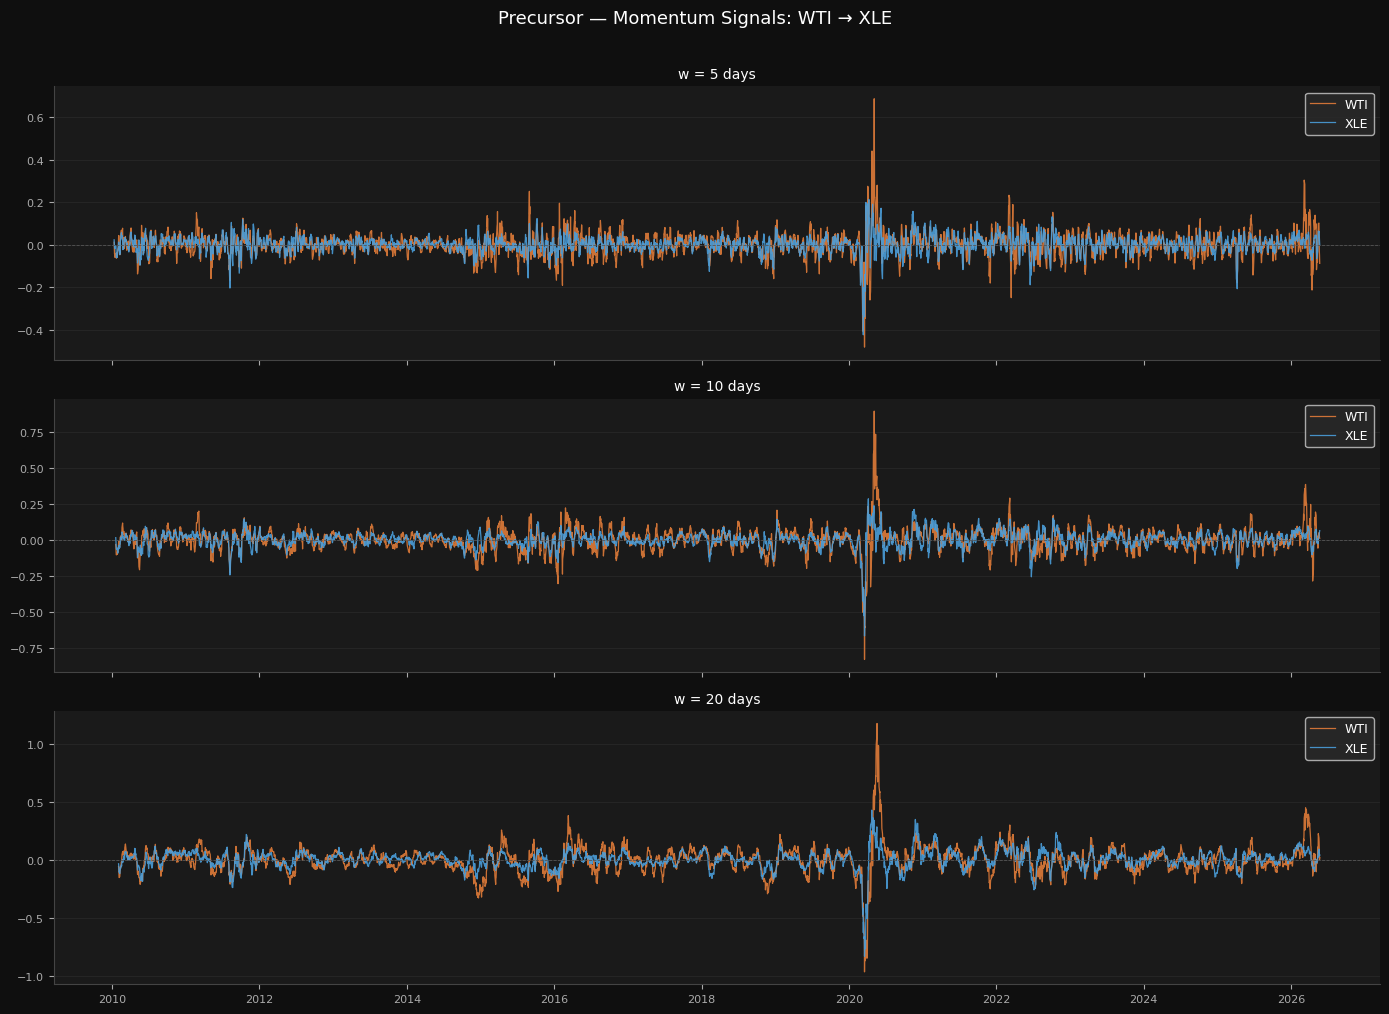

Saved: figures/03_momentum_wti_xle.png


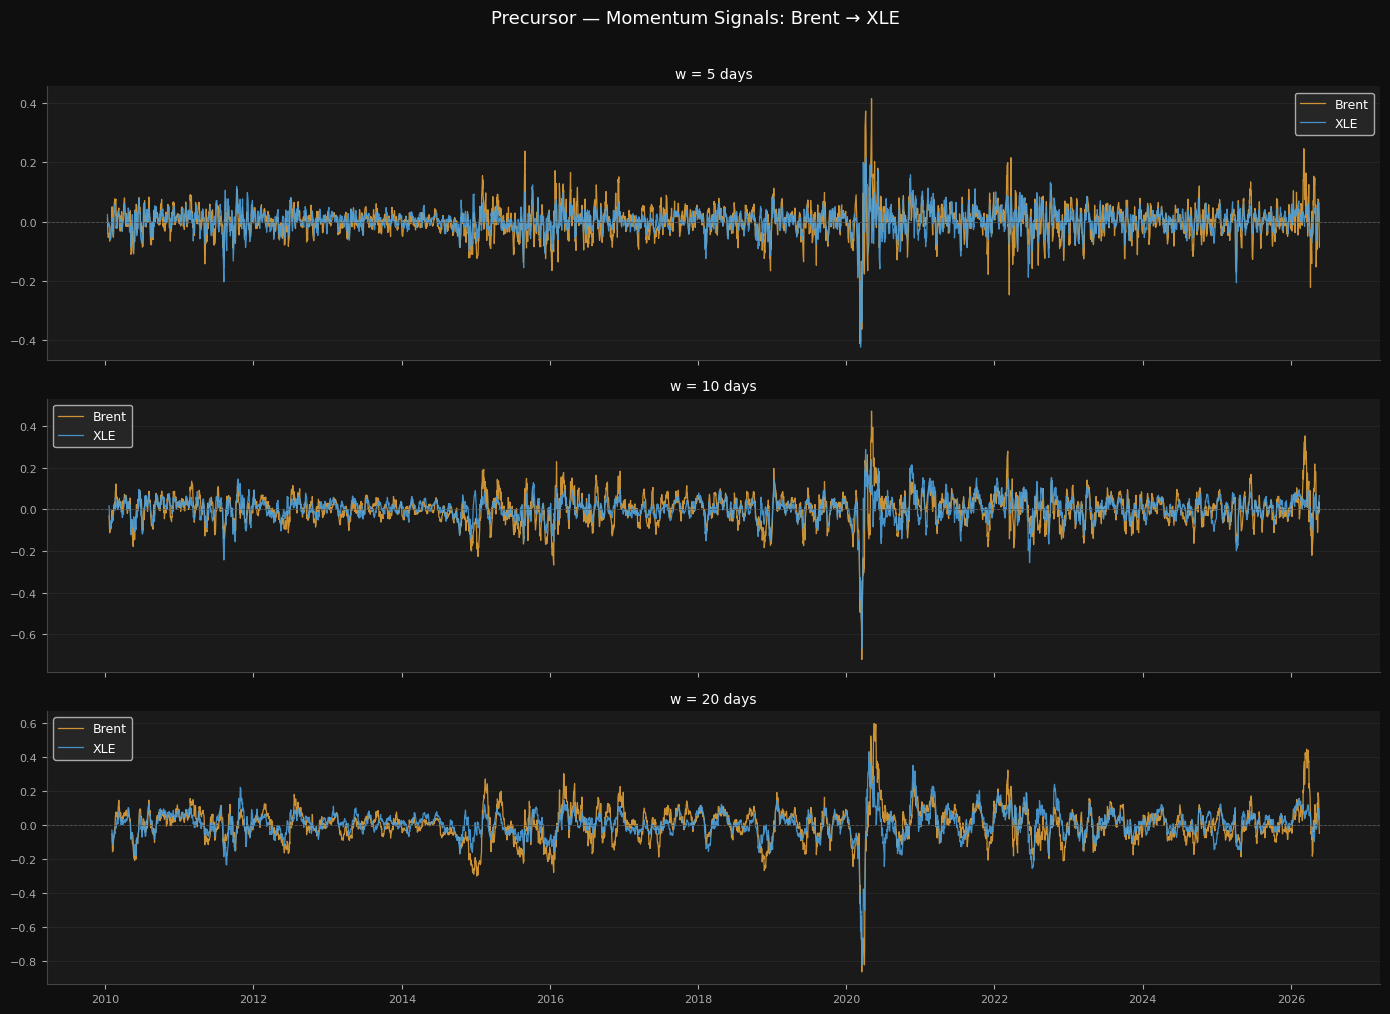

Saved: figures/03_momentum_brent_xle.png


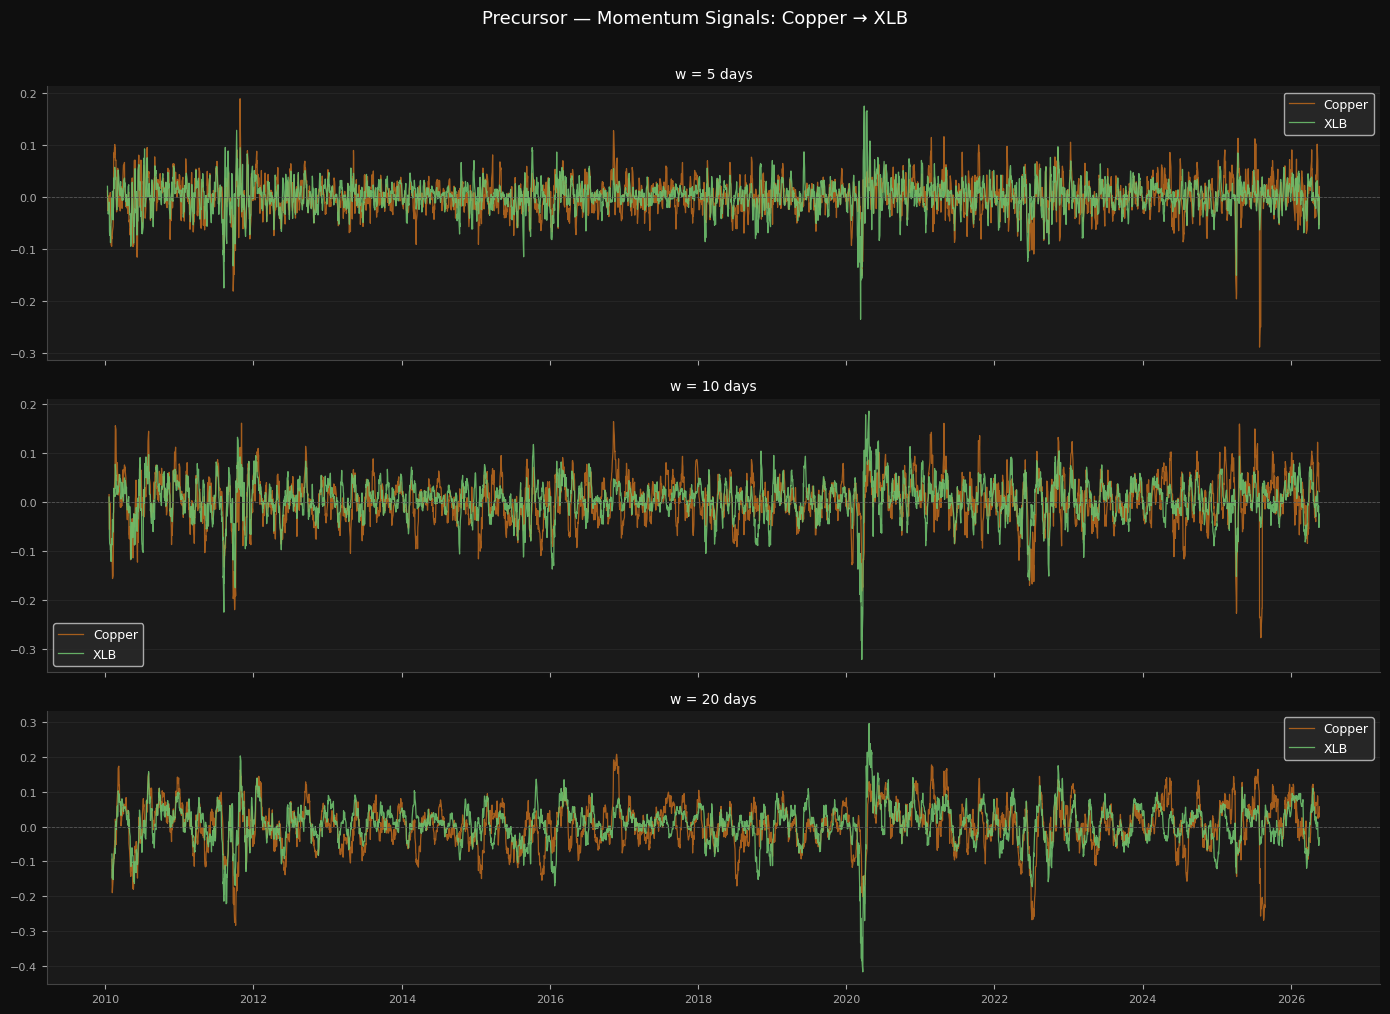

Saved: figures/03_momentum_copper_xlb.png


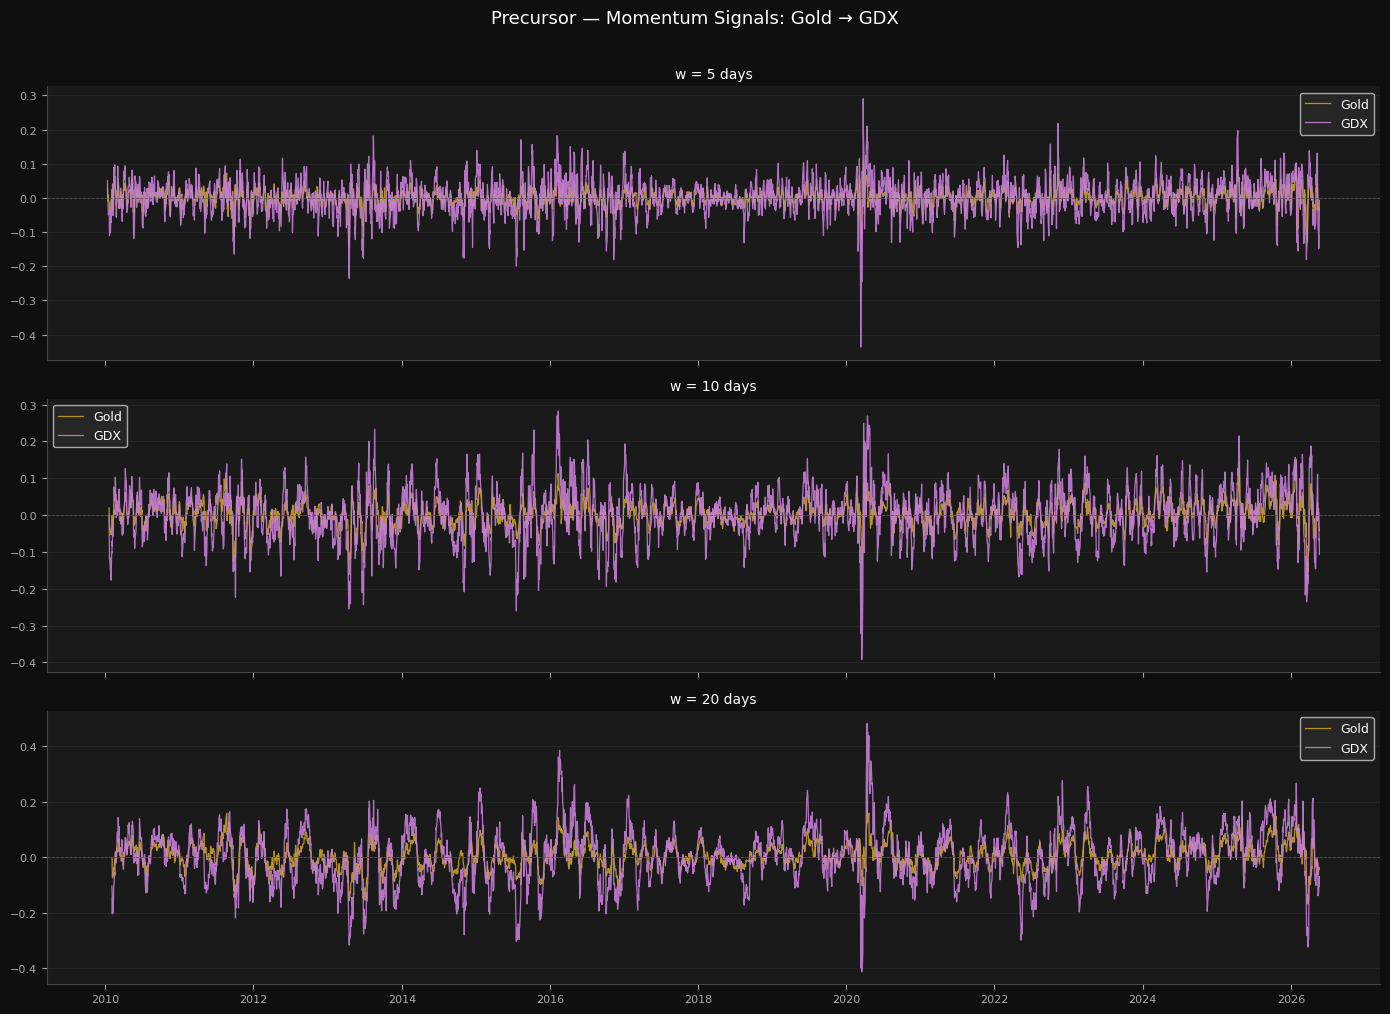

Saved: figures/03_momentum_gold_gdx.png


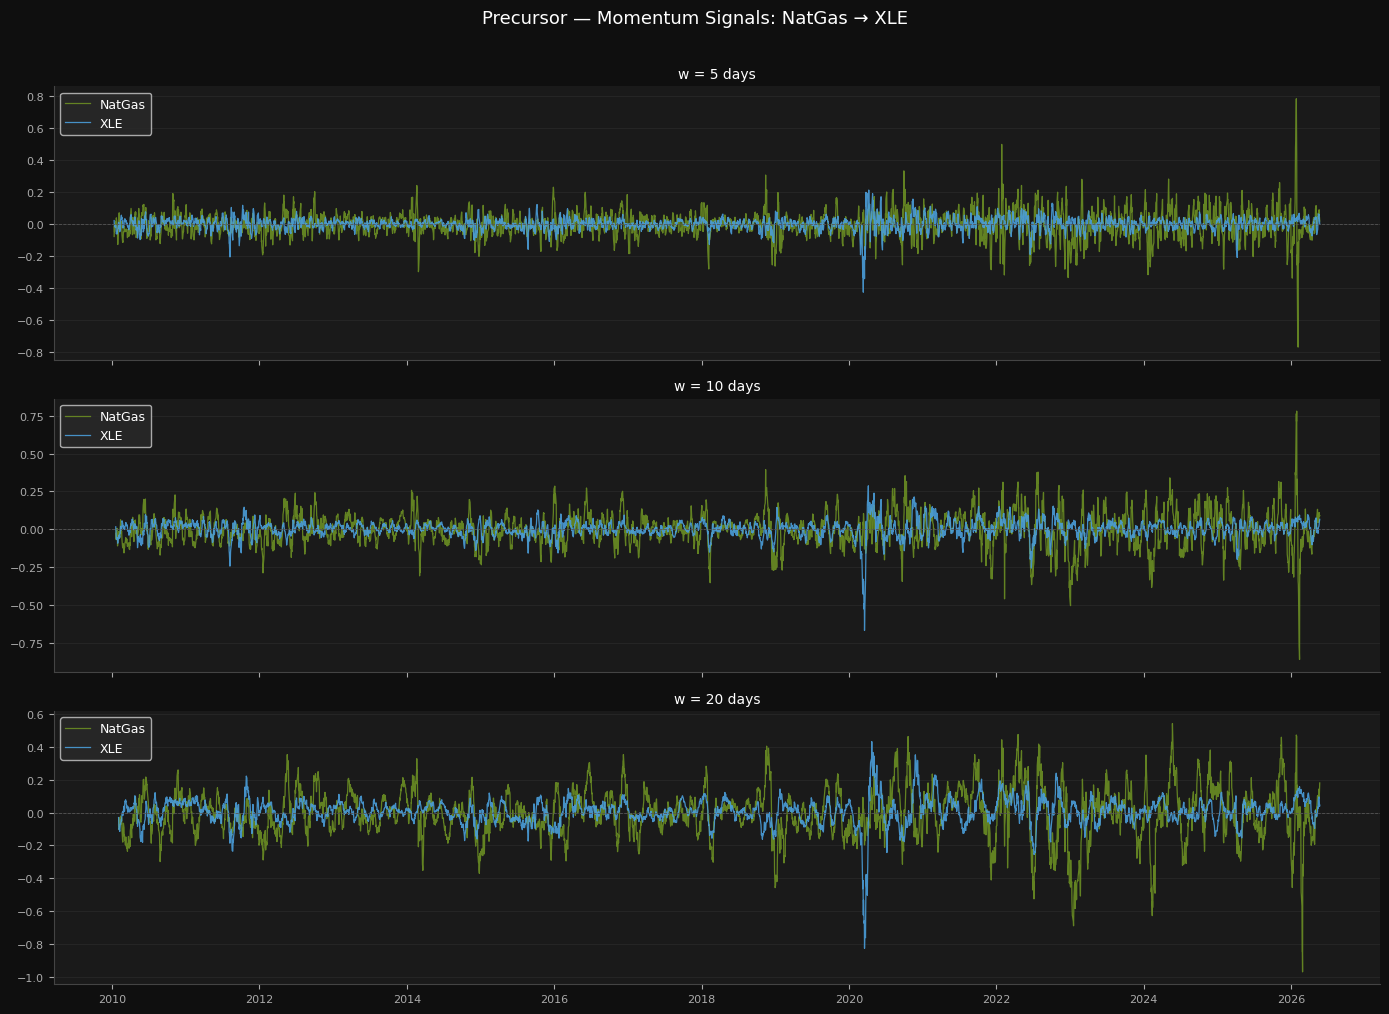

Saved: figures/03_momentum_natgas_xle.png


In [3]:
for comm, eq in PAIRS:
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), facecolor="#0f0f0f", sharex=True)

    for i, w in enumerate(WINDOWS):
        ax = axes[i]
        ax.set_facecolor("#1a1a1a")
        ax.plot(momentum[w].index, momentum[w][comm], color=COLORS[comm], linewidth=0.9, alpha=0.9, label=comm)
        ax.plot(momentum[w].index, momentum[w][eq],   color=COLORS[eq],   linewidth=0.9, alpha=0.9, label=eq)
        ax.axhline(0, color="#555555", linewidth=0.6, linestyle="--")
        ax.set_title(f"w = {w} days", color="white", fontsize=10, pad=6)
        ax.legend(facecolor="#2a2a2a", labelcolor="white", fontsize=9)
        ax.tick_params(colors="#aaaaaa", labelsize=8)
        ax.spines[["top","right"]].set_visible(False)
        ax.spines[["bottom","left"]].set_color("#444444")
        ax.grid(axis="y", color="#2a2a2a", linewidth=0.5)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    fig.suptitle(f"Precursor — Momentum Signals: {comm} → {eq}", color="white", fontsize=13, y=1.01)
    plt.tight_layout()
    fname = f"03_momentum_{comm.lower()}_{eq.lower()}.png"
    plt.savefig(os.path.join(FIG_DIR, fname), dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
    plt.show()
    print(f"Saved: figures/{fname}")

---
### 4. Signal Correlation Across Windows

For each asset, how correlated are signals across different lookback windows? High correlation means the signal is robust to window choice.

In [4]:
print("Signal correlation across windows (per asset)")
print("=" * 50)

for asset in ALL_ASSETS:
    combined = pd.DataFrame({
        f"w={w}": momentum[w][asset] for w in WINDOWS
    }).dropna()
    corr = combined.corr()
    print(f"\n{asset}")
    print(corr.round(3).to_string())

Signal correlation across windows (per asset)

WTI
        w=5   w=10   w=20
w=5   1.000  0.716  0.547
w=10  0.716  1.000  0.749
w=20  0.547  0.749  1.000

Brent
        w=5   w=10   w=20
w=5   1.000  0.707  0.525
w=10  0.707  1.000  0.730
w=20  0.525  0.730  1.000

Copper
        w=5   w=10   w=20
w=5   1.000  0.693  0.470
w=10  0.693  1.000  0.685
w=20  0.470  0.685  1.000

NatGas
        w=5   w=10   w=20
w=5   1.000  0.670  0.486
w=10  0.670  1.000  0.678
w=20  0.486  0.678  1.000

Gold
        w=5   w=10   w=20
w=5   1.000  0.688  0.470
w=10  0.688  1.000  0.687
w=20  0.470  0.687  1.000

XLE
        w=5   w=10   w=20
w=5   1.000  0.716  0.499
w=10  0.716  1.000  0.717
w=20  0.499  0.717  1.000

XLB
        w=5   w=10   w=20
w=5   1.000  0.681  0.476
w=10  0.681  1.000  0.698
w=20  0.476  0.698  1.000

GDX
        w=5  w=10   w=20
w=5   1.000  0.69  0.481
w=10  0.690  1.00  0.690
w=20  0.481  0.69  1.000


---
### 5. Signal Autocorrelation

Momentum signals should exhibit positive autocorrelation — that's the persistence that makes them useful. We check autocorrelation at lags 1–10 for each asset and window.

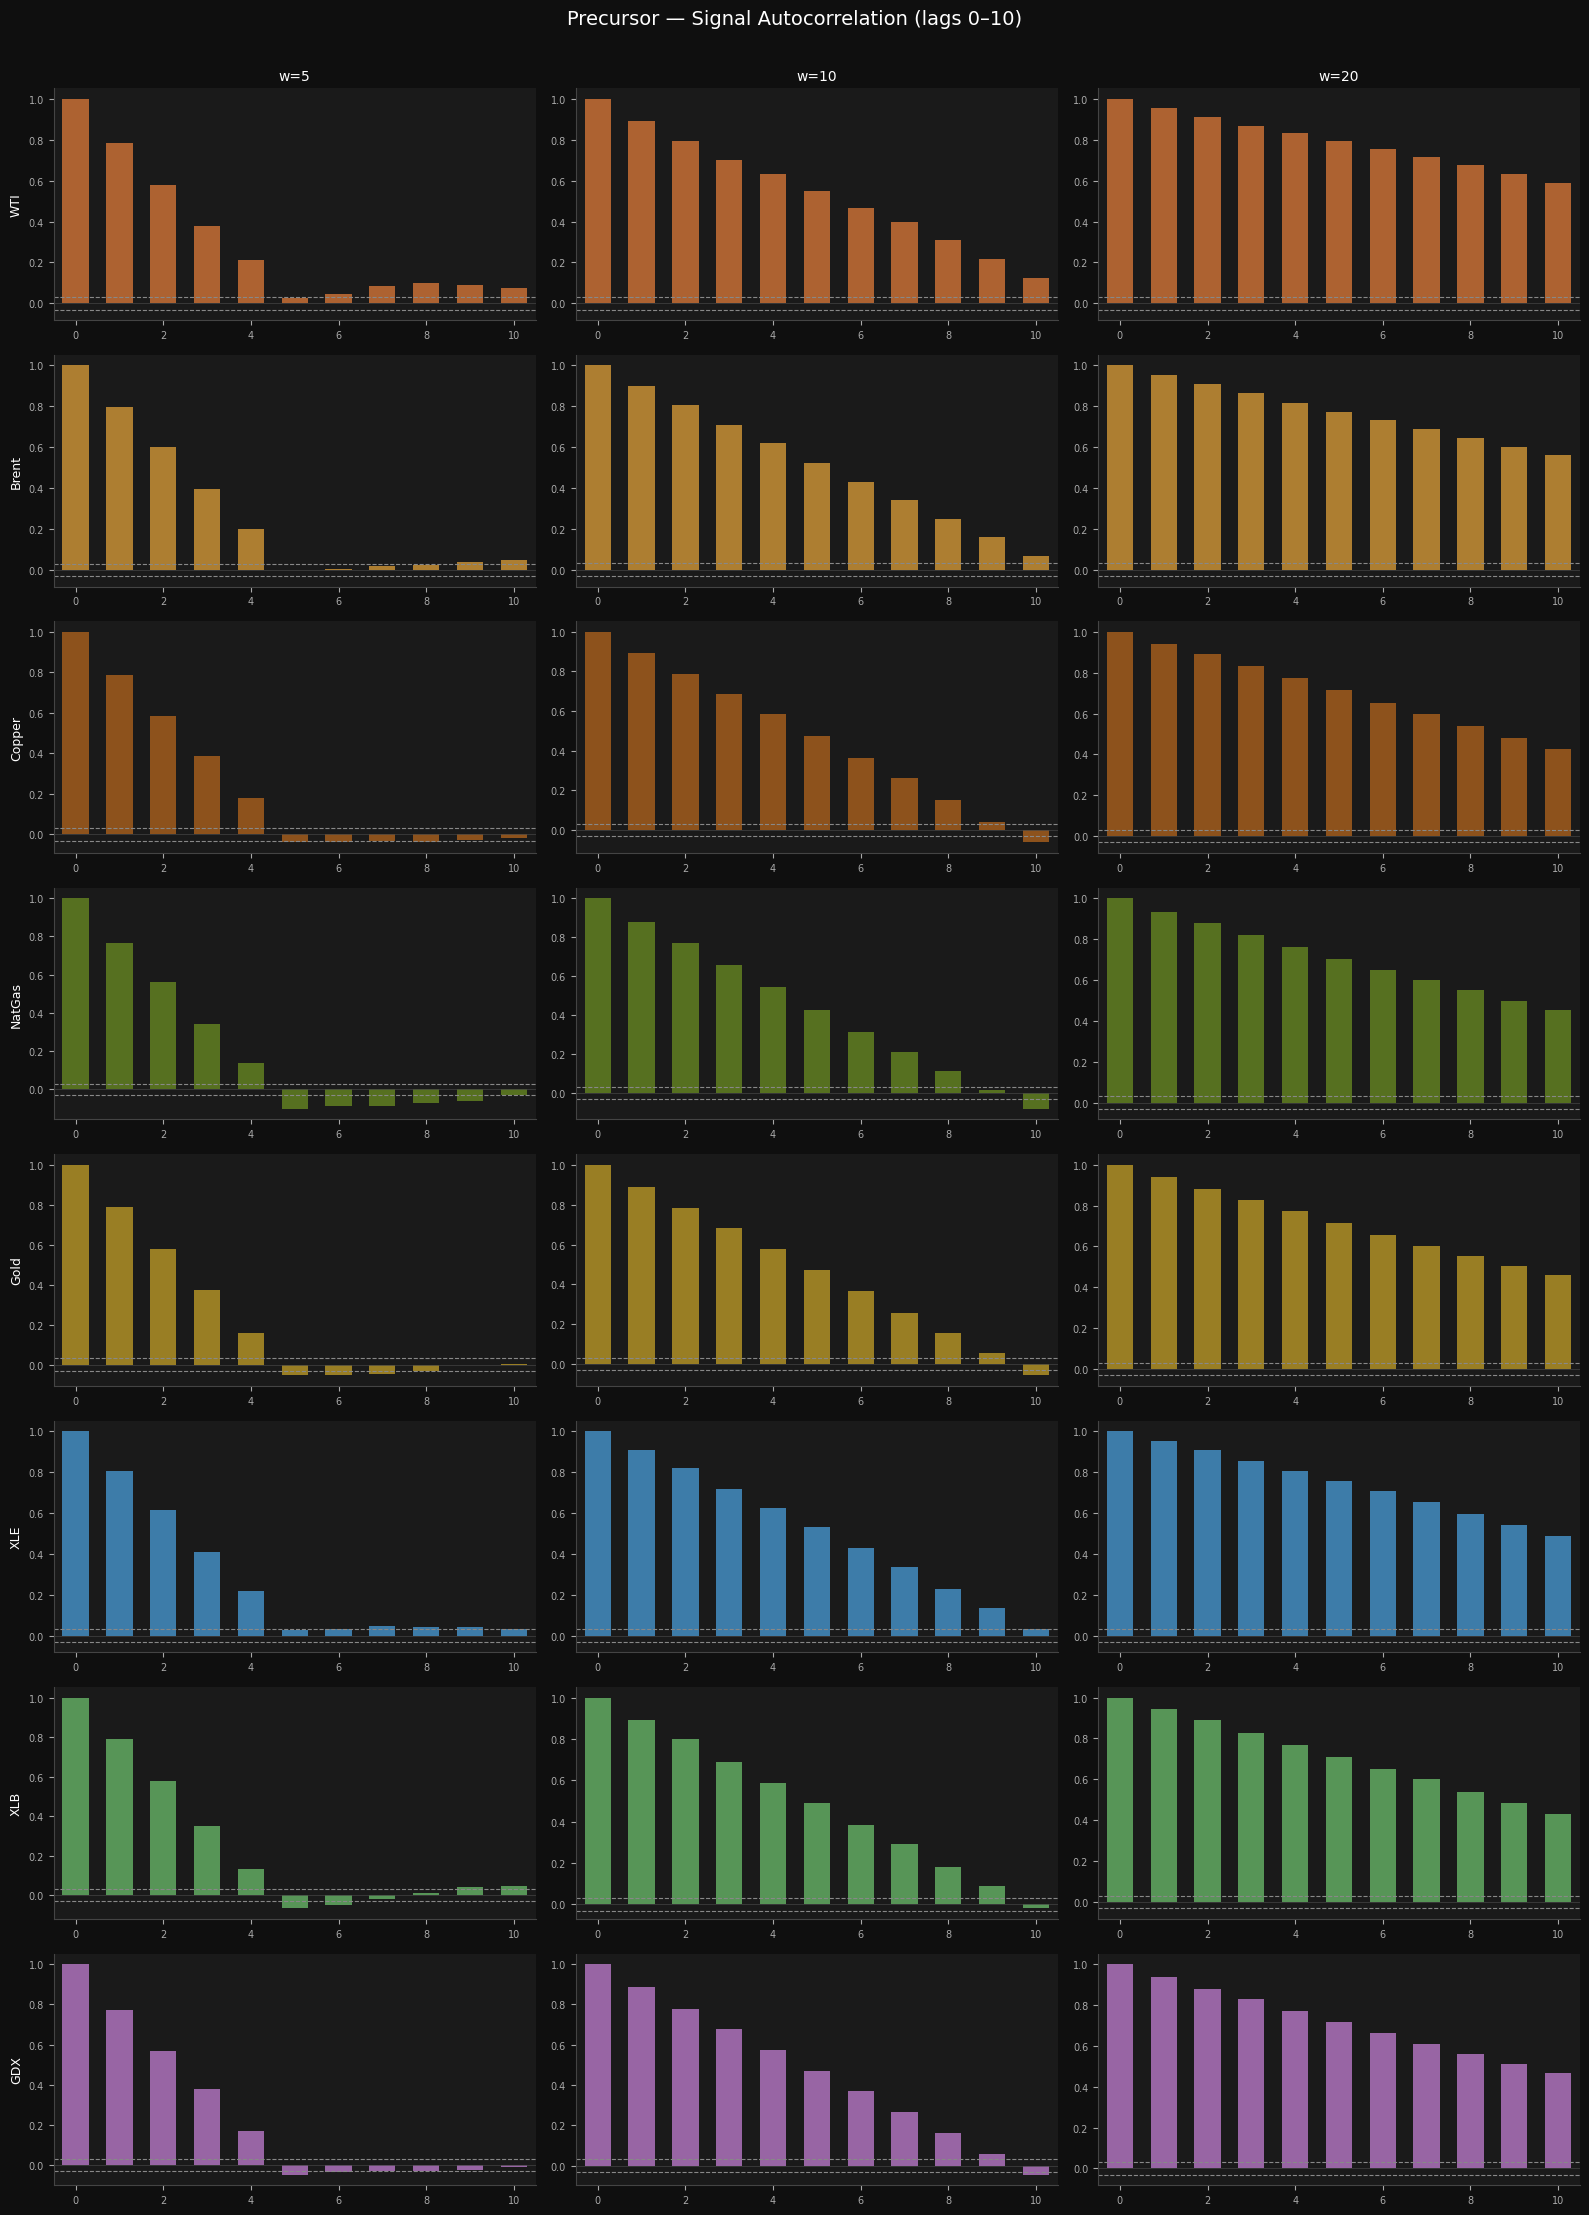

Saved: figures/03_signal_autocorrelation.png


In [5]:
from statsmodels.tsa.stattools import acf

fig, axes = plt.subplots(len(ALL_ASSETS), 3, figsize=(16, 22), facecolor="#0f0f0f")
LAGS = 10

for row, asset in enumerate(ALL_ASSETS):
    for col, w in enumerate(WINDOWS):
        ax = axes[row, col]
        ax.set_facecolor("#1a1a1a")

        series = momentum[w][asset].dropna()
        acf_vals = acf(series, nlags=LAGS, fft=True)
        lag_x = np.arange(len(acf_vals))

        # Confidence interval (95%)
        ci = 1.96 / np.sqrt(len(series))

        ax.bar(lag_x, acf_vals, color=COLORS[asset], alpha=0.75, width=0.6)
        ax.axhline(ci,  color="#888888", linestyle="--", linewidth=0.8)
        ax.axhline(-ci, color="#888888", linestyle="--", linewidth=0.8)
        ax.axhline(0,   color="#444444", linewidth=0.5)

        if row == 0:
            ax.set_title(f"w={w}", color="white", fontsize=10)
        if col == 0:
            ax.set_ylabel(asset, color="white", fontsize=9)

        ax.tick_params(colors="#aaaaaa", labelsize=7)
        ax.spines[["top","right"]].set_visible(False)
        ax.spines[["bottom","left"]].set_color("#444444")
        ax.set_xlim(-0.5, LAGS + 0.5)

fig.suptitle("Precursor — Signal Autocorrelation (lags 0–10)", color="white", fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "03_signal_autocorrelation.png"), dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("Saved: figures/03_signal_autocorrelation.png")

---
### 6. Lead-Lag Scatter Plots

For each hypothesised pair, scatter the commodity momentum at time $t-k$ against the equity momentum at time $t$, for lags $k \in \{1, 2, 3, 5\}$. A visible trend here is a visual precursor to the formal Granger test in notebook 04.

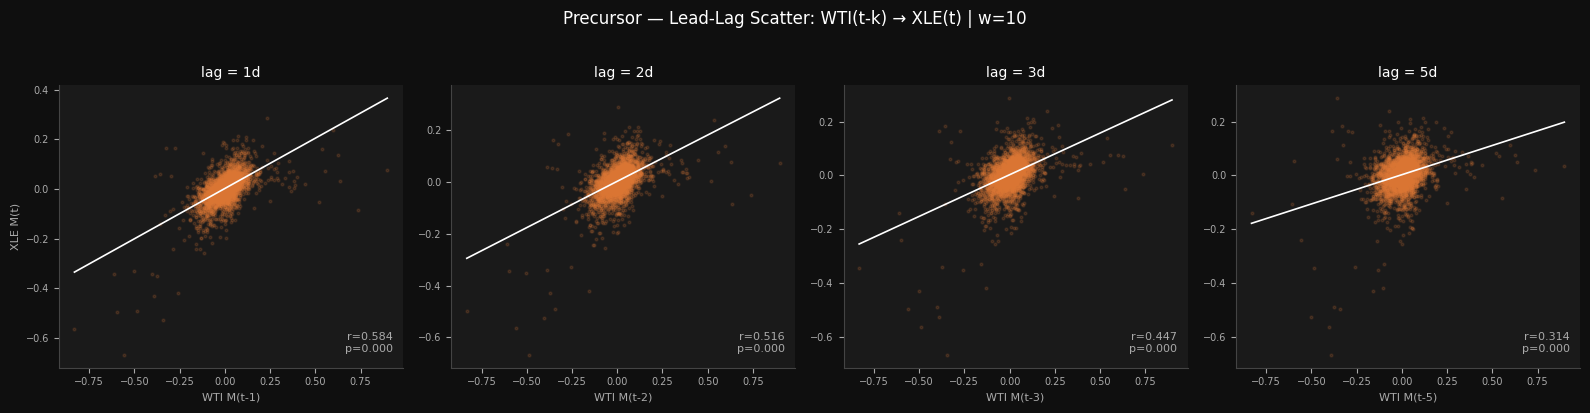

Saved: figures/03_leadlag_wti_xle.png


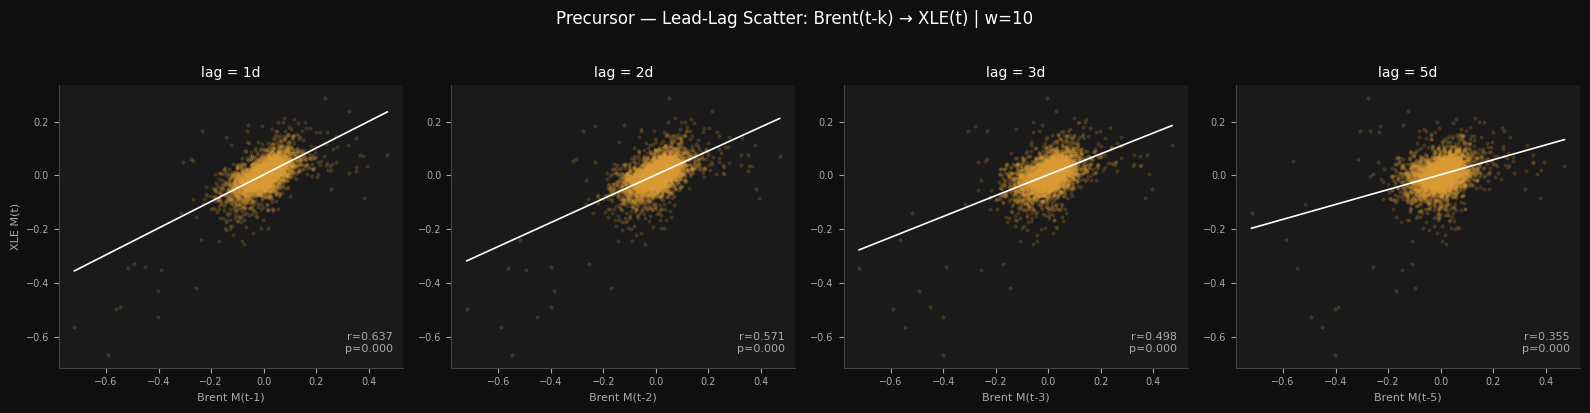

Saved: figures/03_leadlag_brent_xle.png


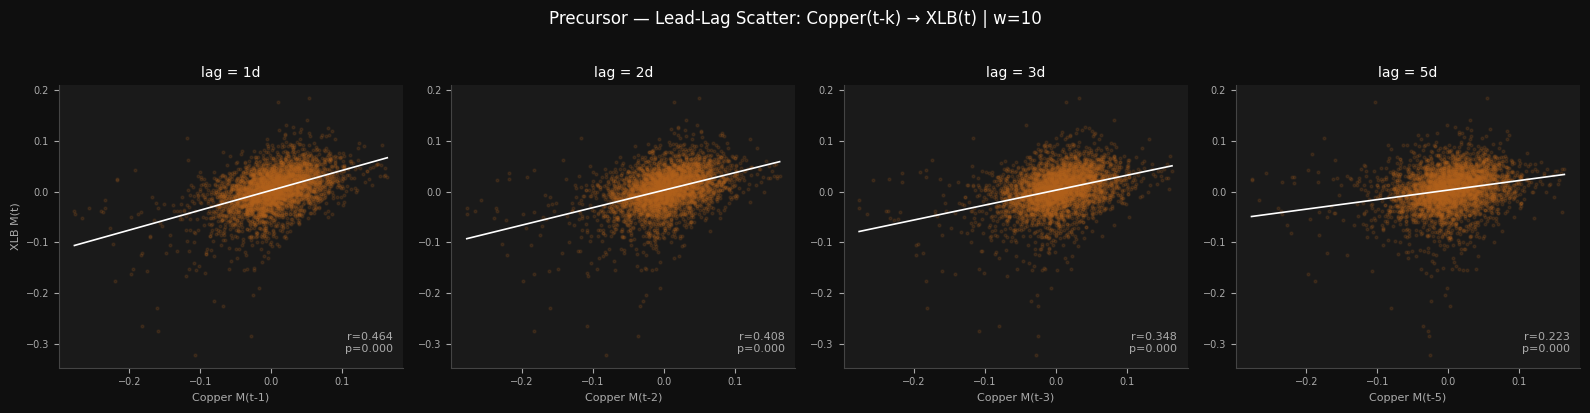

Saved: figures/03_leadlag_copper_xlb.png


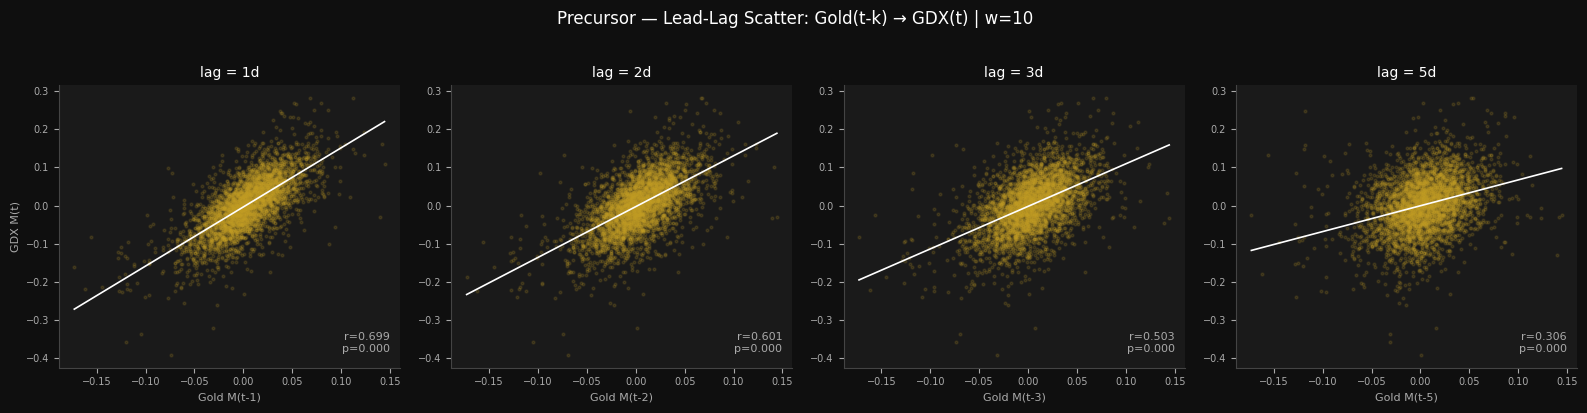

Saved: figures/03_leadlag_gold_gdx.png


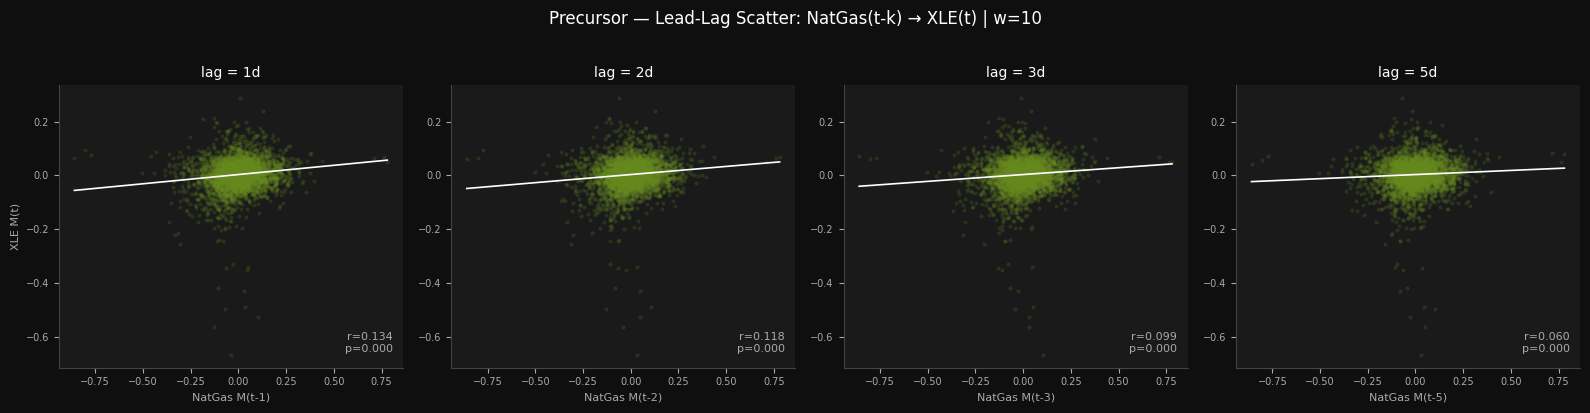

Saved: figures/03_leadlag_natgas_xle.png


In [6]:
W = 10  # use 10-day window for this analysis
LAGS_SCATTER = [1, 2, 3, 5]

for comm, eq in PAIRS:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), facecolor="#0f0f0f")

    for i, lag in enumerate(LAGS_SCATTER):
        ax = axes[i]
        ax.set_facecolor("#1a1a1a")

        x = momentum[W][comm].shift(lag)
        y = momentum[W][eq]
        df_scatter = pd.DataFrame({"x": x, "y": y}).dropna()

        ax.scatter(df_scatter["x"], df_scatter["y"],
                   alpha=0.15, s=4, color=COLORS[comm])

        # OLS regression line
        slope, intercept, r, p, _ = stats.linregress(df_scatter["x"], df_scatter["y"])
        x_line = np.linspace(df_scatter["x"].min(), df_scatter["x"].max(), 100)
        ax.plot(x_line, intercept + slope * x_line, color="white", linewidth=1.2)

        ax.set_title(f"lag = {lag}d", color="white", fontsize=10)
        ax.set_xlabel(f"{comm} M(t-{lag})", color="#aaaaaa", fontsize=8)
        if i == 0:
            ax.set_ylabel(f"{eq} M(t)", color="#aaaaaa", fontsize=8)
        ax.tick_params(colors="#aaaaaa", labelsize=7)
        ax.spines[["top","right"]].set_visible(False)
        ax.spines[["bottom","left"]].set_color("#444444")
        ax.text(0.97, 0.05, f"r={r:.3f}\np={p:.3f}",
                transform=ax.transAxes, ha="right", va="bottom",
                color="#aaaaaa", fontsize=8)

    fig.suptitle(f"Precursor — Lead-Lag Scatter: {comm}(t-k) → {eq}(t) | w={W}",
                 color="white", fontsize=12, y=1.02)
    plt.tight_layout()
    fname = f"03_leadlag_{comm.lower()}_{eq.lower()}.png"
    plt.savefig(os.path.join(FIG_DIR, fname), dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
    plt.show()
    print(f"Saved: figures/{fname}")

---
### 7. Save Momentum Signals

In [7]:
for w in WINDOWS:
    path = os.path.join(PROC_DIR, f"momentum_w{w}.csv")
    momentum[w].to_csv(path)
    print(f"Saved: {path}  |  shape: {momentum[w].shape}")

print("\nAll momentum signals saved.")

Saved: ..\data\processed\momentum_w5.csv  |  shape: (4122, 8)
Saved: ..\data\processed\momentum_w10.csv  |  shape: (4122, 8)
Saved: ..\data\processed\momentum_w20.csv  |  shape: (4122, 8)

All momentum signals saved.


---
### 8. Summary

| Output | Path |
|---|---|
| Momentum signals (w=5)  | `data/processed/momentum_w5.csv` |
| Momentum signals (w=10) | `data/processed/momentum_w10.csv` |
| Momentum signals (w=20) | `data/processed/momentum_w20.csv` |
| Pair signal plots       | `figures/03_momentum_{pair}.png` |
| Autocorrelation plot    | `figures/03_signal_autocorrelation.png` |
| Lead-lag scatter plots  | `figures/03_leadlag_{pair}.png` |

**What to look for in the lead-lag scatters:**
- A positive slope at lag 1–2 days suggests the commodity leads the equity
- r values above ~0.05 with p < 0.05 are worth pursuing in the formal Granger test
- NatGas → XLE is expected to be weak; WTI/Brent → XLE should show the clearest signal